# ETL

Content

Attribute Information:

* InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned
to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
* StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
* Description: Product (item) name. Nominal.
* Quantity: The quantities of each product (item) per transaction. Numeric.
* InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
* UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£).
* CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
* Country: Country name. Nominal. The name of the country where a customer resides.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/MyDrive/Datasets/online_retail_II.csv')

Mounted at /content/gdrive


In [3]:
display(df)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
df = df.dropna(subset=['Customer ID']).copy()

In [8]:
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
df = df[df['Quantity'] > 0]

In [12]:
df = df[df['Price'] > 0]

In [13]:
df['TotalRevenue'] = df['Quantity'] * df['Price']

In [24]:
df = df[~df['Invoice'].str.startswith('C')]

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       805549 non-null  object        
 1   StockCode     805549 non-null  object        
 2   Description   805549 non-null  object        
 3   Quantity      805549 non-null  int64         
 4   InvoiceDate   805549 non-null  datetime64[ns]
 5   Price         805549 non-null  float64       
 6   Customer ID   805549 non-null  object        
 7   Country       805549 non-null  object        
 8   TotalRevenue  805549 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 61.5+ MB


# EDA

In [32]:
revenue_by_country = df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False)
percentage_by_country = (revenue_by_country / revenue_by_country.sum()) * 100
geo_summary = pd.DataFrame({
    'Receita Total (£)': revenue_by_country,
    'Representatividade (%)': percentage_by_country.round(2)
})
display(geo_summary.head(10))

,Receita Total (£),Representatividade (%)
Country,,
United Kingdom,1.472315e+07,82.98
EIRE,6.216311e+05,3.50
Netherlands,5.542323e+05,3.12
Germany,4.312625e+05,2.43
France,3.552575e+05,2.00
Australia,1.699681e+05,0.96
Spain,1.091785e+05,0.62
Switzerland,1.003653e+05,0.57
Sweden,9.154972e+04,0.52


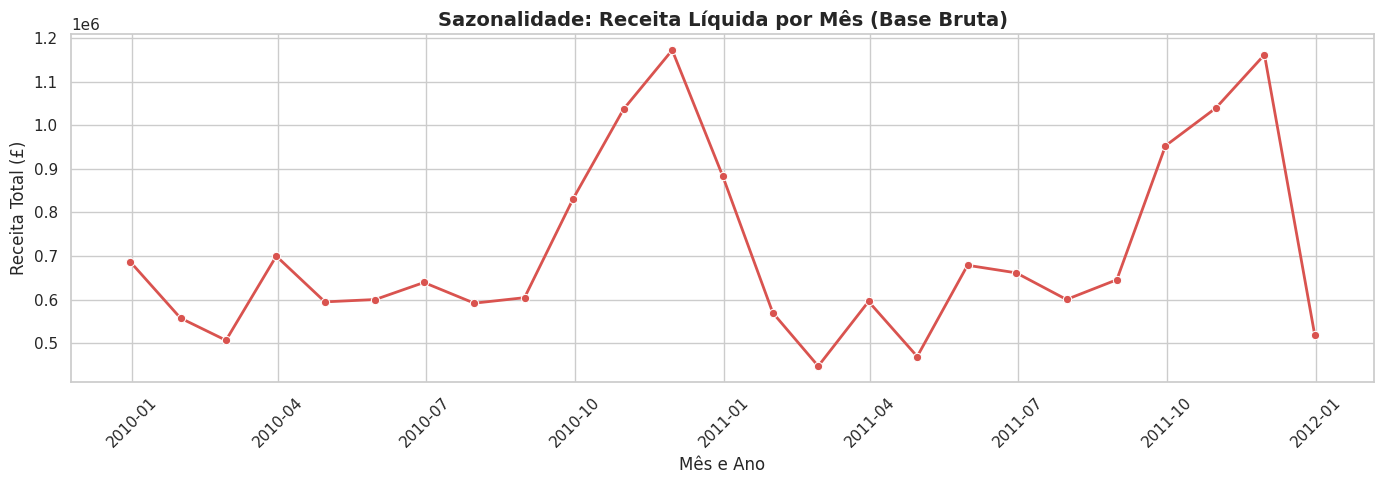

In [31]:
sns.set_theme(style="whitegrid")

if 'TotalRevenue' not in df.columns:
    df['TotalRevenue'] = df['Quantity'] * df['Price']
monthly_revenue_raw = df.set_index('InvoiceDate').resample('ME')['TotalRevenue'].sum()

plt.figure(figsize=(14, 5))
sns.lineplot(x=monthly_revenue_raw.index, y=monthly_revenue_raw.values, marker='o', color='#d9534f', linewidth=2)
plt.title('Sazonalidade: Receita Líquida por Mês (Base Bruta)', fontsize=14, fontweight='bold')
plt.xlabel('Mês e Ano')
plt.ylabel('Receita Total (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
df['Description'].nunique()

5283

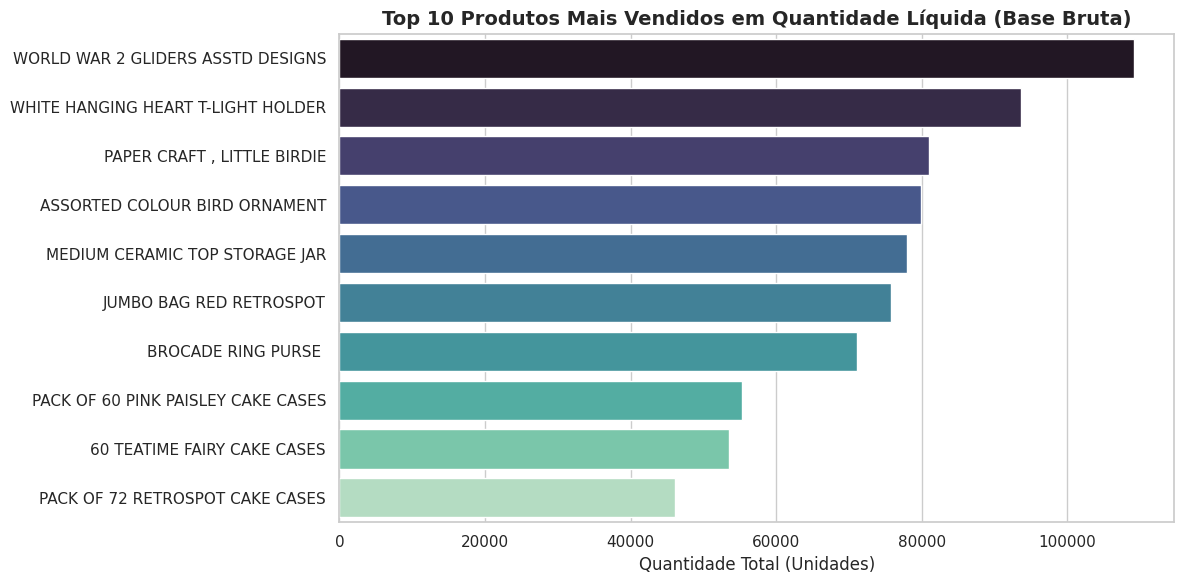

In [30]:
sns.set_theme(style="whitegrid")

top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_qty.values, y=top_products_qty.index, hue=top_products_qty.index, palette="mako", legend=False)

plt.title('Top 10 Produtos Mais Vendidos em Quantidade Líquida (Base Bruta)', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade Total (Unidades)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# TABELA RFM

Recência: dias desde a última compra

Frequência: contagem de notas fiscais únicas

Monetário: soma da receita total

In [35]:
import datetime as dt

data_referencia = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Data de referência para o cálculo: {data_referencia}")

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (data_referencia - x.max()).days,
    'Invoice': 'nunique',
    'TotalRevenue': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalRevenue': 'Monetary'
}, inplace=True)

display(rfm.head())
print("\nResumo Estatístico do RFM:")
display(rfm.describe())

Data de referência para o cálculo: 2011-12-10 12:50:00


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40



Resumo Estatístico do RFM:


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


# NORMALIZAÇÃO LOGARITMICA E MINMAXSCALER

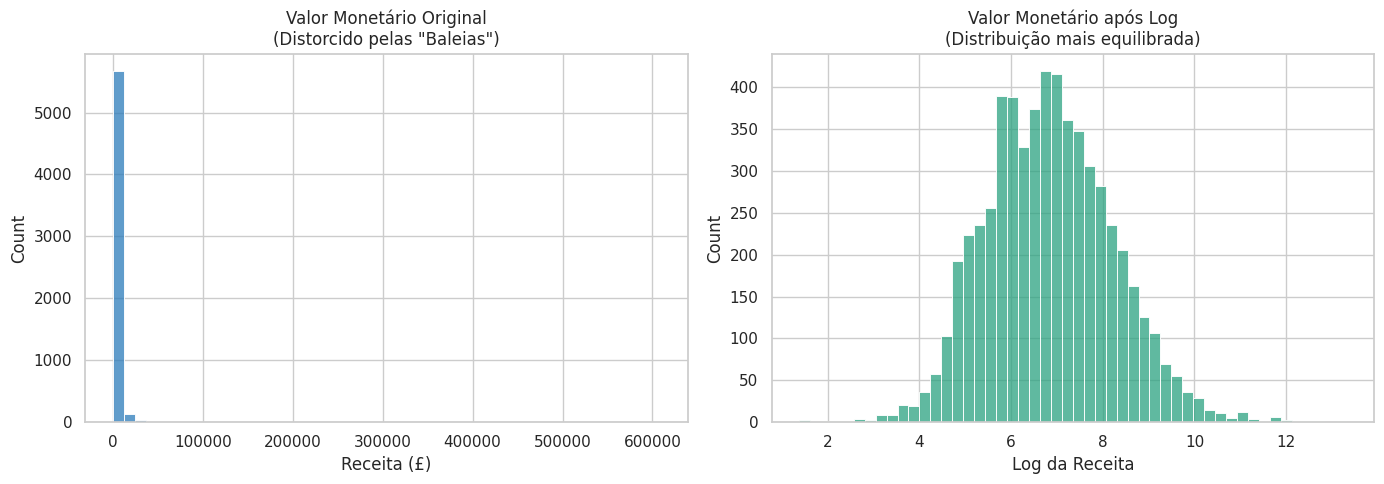

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,4.454132,1.549588,6.836550
std,1.559404,0.809447,1.387864
min,0.693147,0.693147,1.373716
25%,3.295837,0.693147,5.857254
50%,4.574711,1.386294,6.802300
75%,5.942799,2.079442,7.744175
max,6.606650,5.988961,13.319282


In [37]:
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(rfm['Monetary'], bins=50, ax=ax[0], color='#2b7bba')
ax[0].set_title('Valor Monetário Original\n(Distorcido pelas "Baleias")')
ax[0].set_xlabel('Receita (£)')

sns.histplot(rfm_log['Monetary'], bins=50, ax=ax[1], color='#2ba280')
ax[1].set_title('Valor Monetário após Log\n(Distribuição mais equilibrada)')
ax[1].set_xlabel('Log da Receita')

plt.tight_layout()
plt.show()

display(rfm_log.describe())

In [40]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

colunas = ['Recency', 'Frequency', 'Monetary']

rfm_scaled_array = scaler.fit_transform(rfm_log[colunas])

rfm_scaled = pd.DataFrame(rfm_scaled_array, columns=colunas, index=rfm_log.index)

display(rfm_scaled.describe())

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,0.635999,0.161720,0.457311
std,0.263702,0.152847,0.116182
min,0.000000,0.000000,0.000000
25%,0.440127,0.000000,0.375331
50%,0.656390,0.130886,0.454443
75%,0.887740,0.261772,0.533291
max,1.000000,1.000000,1.000000


# CLUSTERING

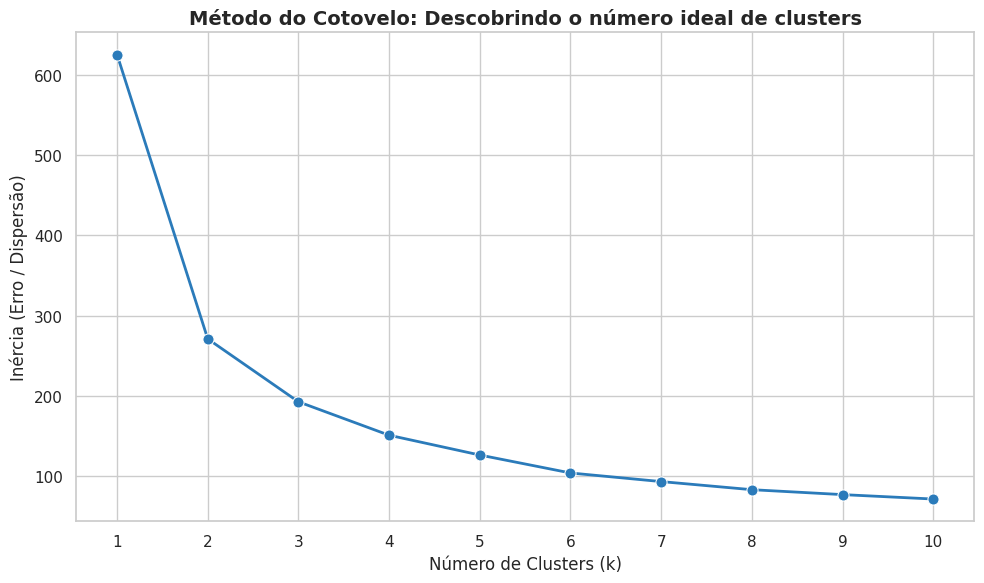

In [41]:
from sklearn.cluster import KMeans

valores_k = range(1, 11)

inercia = []

for k in valores_k:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
sns.lineplot(x=valores_k, y=inercia, marker='o', color='#2b7bba', markersize=8, linewidth=2)
plt.title('Método do Cotovelo: Descobrindo o número ideal de clusters', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (Erro / Dispersão)')
plt.xticks(valores_k)
plt.tight_layout()
plt.show()

Calculando o Silhouette Score... (isso pode levar alguns segundinhos)
Para k = 3, o Silhouette Score é: 0.4055
Para k = 4, o Silhouette Score é: 0.4048
Para k = 5, o Silhouette Score é: 0.3546
Para k = 6, o Silhouette Score é: 0.3636


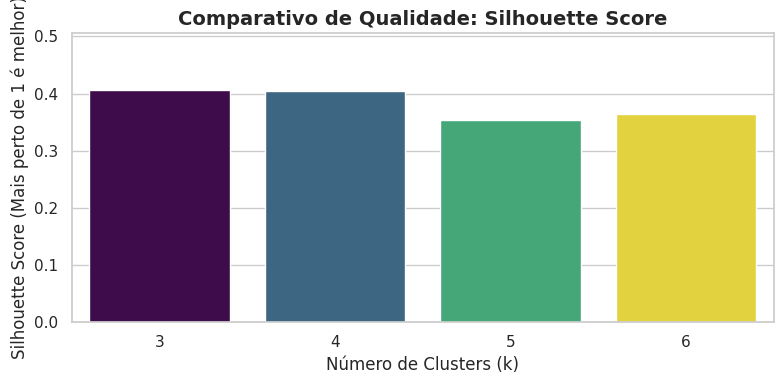

In [42]:
from sklearn.metrics import silhouette_score

valores_k_silhueta = [3, 4, 5, 6]
scores_silhueta = []

print("Calculando o Silhouette Score... (isso pode levar alguns segundinhos)")

for k in valores_k_silhueta:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    scores_silhueta.append(score)

    print(f"Para k = {k}, o Silhouette Score é: {score:.4f}")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.barplot(x=valores_k_silhueta, y=scores_silhueta, palette='viridis', hue=valores_k_silhueta, legend=False)
plt.title('Comparativo de Qualidade: Silhouette Score', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score (Mais perto de 1 é melhor)')
plt.ylim(0, max(scores_silhueta) + 0.1)
plt.tight_layout()
plt.show()

Com esses resultados decidi usar 4 clusters

* Campeões: Gastam muito, compram sempre e a última compra foi recente. (Foco: Upsell e recompensas exclusivas).

* Fiéis / Recorrentes: Compram com boa frequência, ticket médio razoável, estão ativos. (Foco: Aumentar o ticket médio).

* Em Risco: Já gastaram um bom dinheiro e tinham recorrência, mas a recência está alta (estão parando de comprar). (Foco: Reativação agressiva e promoções).

* Hibernando / Perdidos: Compraram pouco, gastaram pouco e sumiram há muito tempo. (Foco: E-mails em massa baratos para ver se alguém "acorda", sem gastar muito orçamento).

In [43]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

perfil_clusters = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

perfil_clusters.columns = ['Recência Média (Dias)', 'Frequência Média', 'Valor Monetário Médio (£)', 'Qtd de Clientes']

perfil_clusters = perfil_clusters.sort_values(by='Valor Monetário Médio (£)', ascending=False)

display(perfil_clusters)

,Recência Média (Dias),Frequência Média,Valor Monetário Médio (£),Qtd de Clientes
Cluster,,,,
2,10.59,19.33,11096.09,982
3,117.41,8.35,3669.72,1193
0,36.90,2.64,791.50,1313
1,411.93,1.91,598.26,2390


In [44]:
volume_clusters = rfm.groupby('Cluster').agg({
    'Frequency': 'sum',
    'Monetary': 'sum'
}).round(2)

volume_clusters.columns = ['Total de Pedidos (Notas Fiscais)', 'Faturamento Total (£)']

volume_clusters = volume_clusters.sort_values(by='Faturamento Total (£)', ascending=False)

display(volume_clusters)

,Total de Pedidos (Notas Fiscais),Faturamento Total (£)
Cluster,,
2,18982,10896360.52
3,9961,4377973.55
1,4560,1429849.74
0,3466,1039245.37


***

### Cluster 2: Os Campeões
* **A prova:** Recência minúscula (média de 10 dias), frequência altíssima (19 compras) e um ticket estúpido de £ 11.096.
* **O cenário:** São a elite absoluta da loja (982 clientes). Eles sustentam a operação sozinhos.
* **Impacto na Operação:** Movimentam o maior volume da empresa de longe. Já realizaram **18.982 pedidos**, somando um faturamento estrondoso de **£ 10.896.360,52**.

### Cluster 3: Clientes Em Risco
* **A prova:** Os números mostram que eles deixavam um bom dinheiro na mesa (média de £ 3.669) e compravam bastante (8.3 vezes), mas a recência acende um alerta vermelho gigante: estão há quase 4 meses (117 dias) sem comprar nada.
* **O cenário:** Provavelmente são ex-campeões ou clientes de alto valor que sofreram algum atrito logístico ou foram fisgados pela concorrência.
* **Impacto na Operação:** Representam o segundo maior pilar financeiro da loja, com **9.961 pedidos** e **£ 4.377.973,55** de faturamento histórico que estão "vazando" do caixa e em risco de churn definitivo.

### Cluster 0: Recorrentes / Promissores
* **A prova:** Estão aquecidos e ativos (última compra há pouco mais de 1 mês), mas a frequência (2.6) e o gasto (£ 791) ainda são tímidos.
* **O cenário:** É a base do dia a dia. Eles confiam na loja, mas ainda precisam de um empurrãozinho para aumentar o ticket médio e a frequência.
* **Impacto na Operação:** Trazem um fluxo constante e seguro de caixa, somando **3.466 pedidos** e um faturamento total de **£ 1.039.245,37**.

### Cluster 1: Hibernando / Perdidos
* **A prova:** Estão há mais de um ano (411 dias) sem dar as caras, com menos de 2 compras na vida e ticket muito baixo (média de £ 598).
* **O cenário:** É o maior grupo em volume absoluto de pessoas (2.390 clientes), formando o clássico "cemitério" das bases de e-commerce.
* **Impacto na Operação:** Apesar de representarem o maior esforço de aquisição (maior número de clientes) e terem feito **4.560 pedidos** no passado, geraram apenas **£ 1.429.849,74** no total (baixo valor agregado) e não trazem mais dinheiro novo.

***